In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config_presets.tools.get_config import get_config


config = get_config('Daniel/VM_uncertainty')

endpoint_list = config['columns']['labels']

endpoint_list

ValueError: Config file not found. Please check the toxicity_configs folder.

In [114]:
# df_DE_Xerostomia = pd.read_csv("/home/macraedc/rt_pred_results/Deep Ensemble/Xerostomia_ResNet_2mm_no_decay_higher_lr/all_predictions.csv", sep=';')
# df_MC_Xerostomia = pd.read_csv("/home/macraedc/rt_pred_results/TESTING FRAMEWORK/Xerostomia_M06_2/model_1/all_predictions.csv", sep=';')
# df_TTA_Xerostomia = pd.read_csv("/home/macraedc/rt_pred_results/TTA/Xerostomia_ResNet_2mm_no_decay_higher_lr/model_1/all_predictions.csv", sep=';')

# df_DE_Dysphagia = pd.read_csv("/home/macraedc/rt_pred_results/Deep Ensemble/Dysphagia_ResNet_2mm_no_decay_higher_lr/all_predictions.csv", sep=';')
# df_MC_Dysphagia = pd.read_csv("/home/macraedc/rt_pred_results/TESTING FRAMEWORK/Dysphagia_1/model_1/all_predictions.csv", sep=';')
# df_TTA_Dysphagia = pd.read_csv("/home/macraedc/rt_pred_results/TTA/Dysphagia_ResNet_2mm_no_decay_higher_lr/model_1/all_predictions.csv", sep=';')

# df_DE_OS = pd.read_csv("/home/macraedc/rt_pred_results/Deep Ensemble/Baoqiang_OS_2year/all_predictions.csv", sep=';')   # Baoqiang_OS_2year
# df_MC_OS = pd.read_csv("/home/macraedc/rt_pred_results/MC Dropout/Baoqiang_OS_2year/model_1/all_predictions.csv", sep=';')
# df_TTA_OS = pd.read_csv("/home/macraedc/rt_pred_results/TTA/Baoqiang_OS_2year/model_1/all_predictions.csv", sep=';')


# df_DE_LRC = pd.read_csv("/home/macraedc/rt_pred_results/Deep Ensemble/Baoqiang_LRC_2year/all_predictions.csv", sep=';')
# df_MC_LRC = pd.read_csv("/home/macraedc/rt_pred_results/MC Dropout/Baoqiang_LRC_2year/model_1/all_predictions.csv", sep=';')
# df_TTA_LRC = pd.read_csv("/home/macraedc/rt_pred_results/TTA/Baoqiang_LRC_2year/model_1/all_predictions.csv", sep=';')


df_MC_OS = pd.read_csv("/home/macraedc/rt_pred_results/Tune MC OS/10/model_1/all_predictions.csv", sep=';')
df_DE_OS = pd.read_csv("/home/macraedc/rt_pred_results/Tune MC OS/20/model_1/all_predictions.csv", sep=';')
df_TTA_OS = pd.read_csv("/home/macraedc/rt_pred_results/Tune MC OS/30/model_1/all_predictions.csv", sep=';')
df_CP_OS = pd.read_csv("/home/macraedc/rt_pred_results/Tune MC OS/40/model_1/all_predictions.csv", sep=';')


ALL_DFS_DICT = {
    # "Xerostomia_M06": {
    #     "MC Dropout" : df_MC_Xerostomia,
    #     "Deep Ensemble": df_DE_Xerostomia,
    #     "TTA": df_TTA_Xerostomia
    # },
    # "Dysphagia_M06": {
    #     "MC Dropout": df_MC_Dysphagia,
    #     "Deep Ensemble": df_DE_Dysphagia,
    #     "TTA": df_TTA_Dysphagia
    #     },
    "OS_2year_censored" : {
        "MC Dropout": df_MC_OS,
        "Deep Ensemble": df_DE_OS,
        "TTA": df_TTA_OS,
        "Conformal" : df_CP_OS
    },
    # "LRC_2year_censored": {
    #     "MC Dropout": df_MC_LRC,
    #     "Deep Ensemble": df_DE_LRC,
    #     "TTA": df_TTA_LRC
   #  }
    
}

In [115]:
# endpoints = ["Dysphagia_M06", "Xerostomia_M06"]
# dropouts = ["05", "10", "15", "20", "25", "30", "35", "40", "45", "50"]
# dropouts = ["05", "10", "15", "20", "25", "30", "35", "40", "45", "50"]
# dropouts = ['30']

# DF_metrics = pd.DataFrame()

# #ALL_DFS_DICT = {}

# for endpoint in endpoints:

#     #ALL_DFS_DICT[endpoint] = {}

#     for dropout in dropouts:
#         endpoint_name = endpoint.split("_")[0]
        
#         all_preds_dir = f"/home/macraedc/rt_pred_results/MC_Dropout/{endpoint_name}_{dropout}/model_1/all_predictions.csv"
#         df_preds = pd.read_csv(all_preds_dir, sep=';')

#         ALL_DFS_DICT[endpoint][f"MC Dropout {dropout}"] = df_preds

#         metrics_dir = f"/home/macraedc/rt_pred_results/MC_Dropout/{endpoint_name}_{dropout}/model_1/test_metrics.csv"
#         df_metrics = pd.read_csv(metrics_dir, sep=';', index_col=0)
#         df_metrics = df_metrics[endpoint].to_dict()
#         df_metrics['Endpoint'] = endpoint
#         df_metrics['Dropout'] = dropout

#         df_metrics = pd.DataFrame(df_metrics, index=[0])

#         DF_metrics = pd.concat([DF_metrics, df_metrics], ignore_index=True)

        

In [116]:
# import seaborn as sns

# import matplotlib.pyplot as plt

# sns.barplot(data=DF_metrics, x='Dropout', y='AUC', hue='Endpoint')
# plt.title('MC Dropout AUC by Endpoint and Dropout Rate')
# plt.show()

# sns.barplot(data=DF_metrics, x='Dropout', y='ECE', hue='Endpoint')
# plt.title('MC Dropout ECE by Endpoint and Dropout Rate')
# plt.show()

# sns.barplot(data=DF_metrics, x='Dropout', y='ACE', hue='Endpoint')
# plt.title('MC Dropout AUC by Endpoint and Dropout Rate')
# plt.show()

In [117]:
%load_ext autoreload
%autoreload 2

from src.uncertainty.metrics.mutual_information import mutual_information
from src.uncertainty.metrics.entropy import binary_entropy
from src.uncertainty.metrics.variance import variance

# label_columns = [x + '_true' for x in endpoint_list]
# pred_columns = [col for col in df_MC_Xerostomia.columns if 'pred' in col]
# pred_columns_dict = {endpoint: [col for col in df_MC_Xerostomia.columns if endpoint+"_pred" in col] for endpoint in endpoint_list}

UQ_RESULTS_DICT = {
   # "Xerostomia_M06" : {},
   # "Dysphagia_M06": {},
    "OS_2year_censored": {},
    #"LRC_2year_censored": {}
                   }

ENDPOINT_TYPES = {
    "Xerostomia_M06": "Binary",
    "Dysphagia_M06": "Binary",
    "OS_2year_censored": "Binary",
    "LRC_2year_censored": "Binary"
    #"OS_2year_no_clinical": "Binary"
    
}


def compute_uncertainty_metrics_for_endpoint(df, endpoint):
#for endpoint in endpoint_list:
    df_UQ_results = pd.DataFrame(index=df.index)

    #label_columns = [x + '_true' for x in endpoint_list]
    endpoint_pred_columns = [col for col in df.columns if 'pred' in col]

    all_endpoint_preds = df[endpoint_pred_columns]
    #all_endpoint_preds = (all_endpoint_preds - all_endpoint_preds.min().min()) / (all_endpoint_preds.max().max() - all_endpoint_preds.min().min())
    mean_endpoint_preds = all_endpoint_preds.mean(axis=1)

    # if endpoint == "OS":
    #     plt.hist(mean_endpoint_preds, bins=50, alpha=0.3)

    df_UQ_results['Mean Prediction'] = mean_endpoint_preds

    if ENDPOINT_TYPES[endpoint] == "Binary":
        df_UQ_results['True Labels'] = df[endpoint + '_true']
    else:
        df_UQ_results['True Label Event'] = df[endpoint + '_event_true'].values
        df_UQ_results['True Months Event'] = df[endpoint + '_months_true'].values
        
    df_UQ_results['Mutual Information'] = mutual_information(all_endpoint_preds)
    df_UQ_results['Binary Entropy'] = binary_entropy(mean_endpoint_preds)
    df_UQ_results['Variance'] =  variance(all_endpoint_preds)

    return df_UQ_results


for endpoint, dfs in ALL_DFS_DICT.items():

    for method, df_all_preds in dfs.items():
        # label_columns = [x + '_true' for x in endpoint_list]
        # pred_columns = [col for col in dfs.columns if 'pred' in col]

        df_UQ_results = compute_uncertainty_metrics_for_endpoint(df_all_preds, endpoint)
        UQ_RESULTS_DICT[endpoint][method] = df_UQ_results


#UQ_methods_list = list(ALL_DFS_DICT["Dysphagia_M06"].keys()) 
UQ_metrics_list = ["Binary Entropy", "Variance", "Mutual Information"]
UQ_methods_list = ['MC Dropout', 'Deep Ensemble', 'TTA', "Conformal"]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


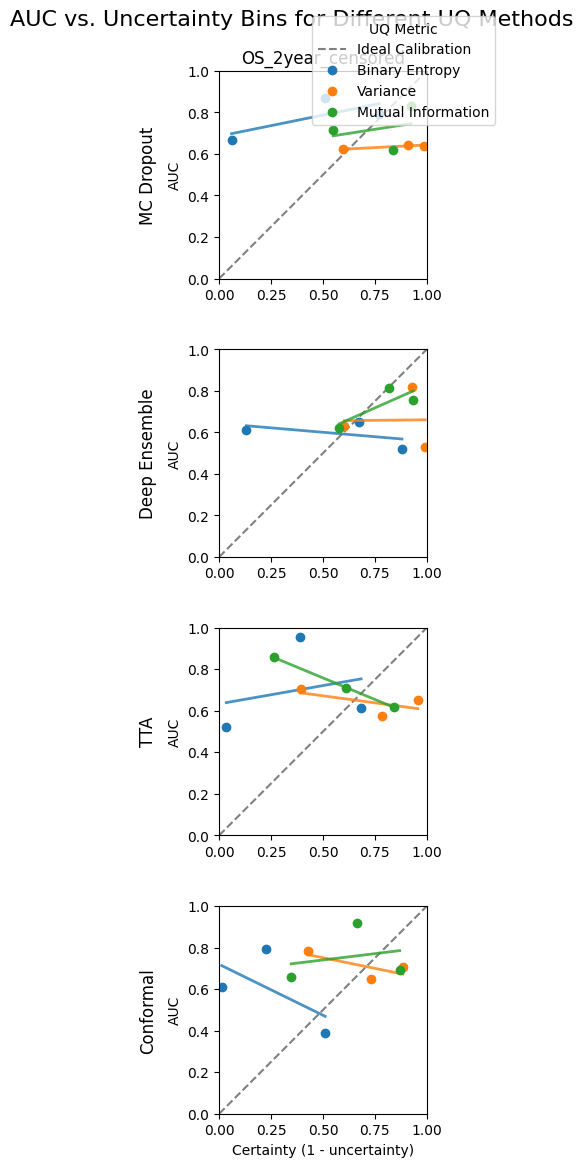

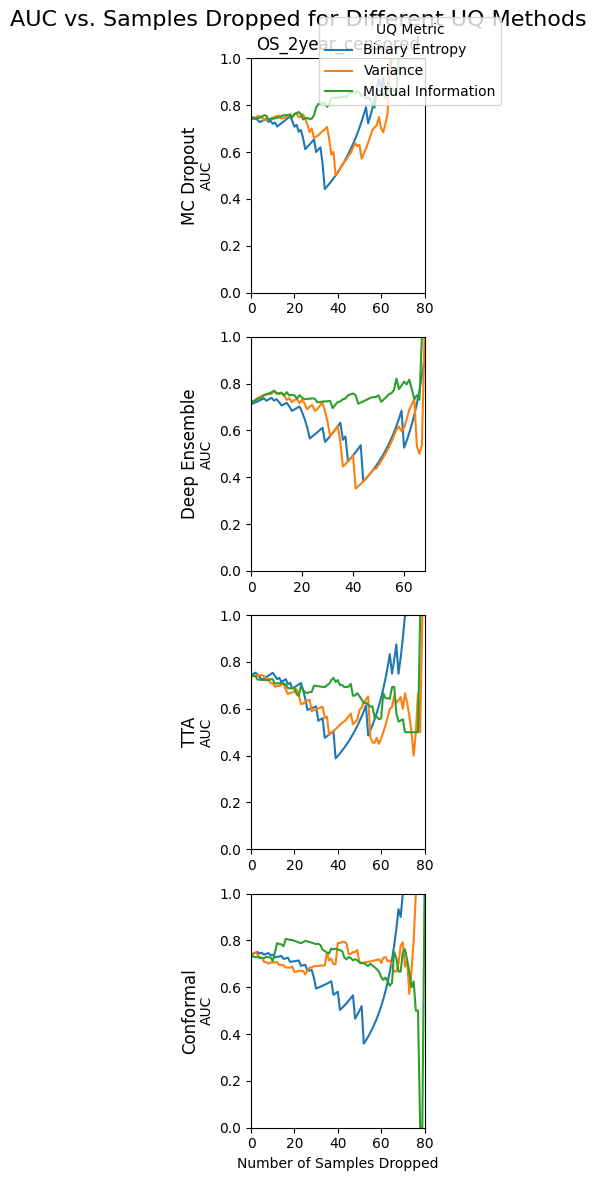

In [118]:
from src.uncertainty.visualisation.plotting_UQ import plot_nested_UQ

fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="calibration", row_key="method", col_key="endpoint", N_bins=3)

plt.show()


fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="sparsification", row_key="method", col_key="endpoint")

plt.show()
